In [2]:
import numpy as np
from pfapack import pfaffian
import matplotlib.pyplot as plt

In [3]:
def gen_tfim(n, J, h, PX = 1):
    H = np.zeros([2 * n, 2 * n], dtype = np.complex128)
    for i in range(n):
        H[2*i, 2*i + 1] = -1.0j * h
    for i in range(n - 1):
        H[2*i+1, 2*i+2] = -1.0j * J
    H[2*n-1, 0] = 1.0j * J * PX
    return 2*(H-H.T) 

In [4]:
def expiHt(H, t):
    e,v = np.linalg.eigh(H)
    return v @ np.diag(np.exp(1.0j * t * e)) @ v.conj().T

In [5]:
def gen_plus(n):
    H = np.zeros([2 * n, 2 * n], dtype = np.complex128)
    for i in range(n):
        H[2*i, 2*i + 1] = 1.0j
    Hsym = H - H.T
    e,v = np.linalg.eigh(Hsym)
    return v[:,:n]

In [6]:
def green_function(state):
    gbar = state@np.linalg.inv(state.T.conj()@state)@state.T.conj()
    return np.eye(np.shape(gbar)[0]) - 2 * gbar 

def gen_mask_for_PZ(N):
    assert N % 2 == 0
    mask = [False] * 2 * N
    for i in range(N//2):
        mask[4*i + 1] = True
        mask[4*i + 2] = True
    return mask

def evaluate_PZ(G, N):
    mask = gen_mask_for_PZ(N)
    A = G[mask,:][:,mask]
    # Ensure A is skew-symmetric by construction to avoid numerical errors
    A = (A - A.T) / 2
    return pfaffian.pfaffian(A) * (-1.0j)**(N//2)

In [7]:
def eta_expiHt(H, t):
    ndim = np.shape(H)[0]
    sinhmiht = expiHt(H, -t/4) - expiHt(H, t/4)
    pfmat = np.zeros([2 * ndim, 2 * ndim], dtype = np.complex128)
    pfmat[:ndim, :ndim]= sinhmiht/np.sqrt(2)
    pfmat[ndim:, ndim:]= sinhmiht/np.sqrt(2)
    pfmat[:ndim, ndim:] = - np.eye(ndim)
    pfmat[ndim:, :ndim] = np.eye(ndim)
    return (-1)**(ndim//2) * pfaffian.pfaffian(pfmat)

In [8]:
def eta_calculate(G1, G2, eta1, eta2):
    ndim = np.shape(G1)[0]
    pfmat = np.zeros([2 * ndim, 2 * ndim], dtype = np.complex128)
    pfmat[:ndim, :ndim]= (G1 - G1.T)/2 
    pfmat[ndim:, ndim:]= (G2 - G2.T)/2
    pfmat[:ndim, ndim:] = - np.eye(ndim)
    pfmat[ndim:, :ndim] = np.eye(ndim)
    return (-1)**(ndim//2) * eta1 * eta2 * pfaffian.pfaffian(pfmat)

def green_function_2(state_left, state_right):
    gbar = state_right@np.linalg.inv(state_left.T.conj()@state_right)@state_left.T.conj()
    return np.eye(np.shape(gbar)[0]) - 2 * gbar 

In [9]:

def parity_Z(N, J, h, t):
    plus_state = gen_plus(N)
    exp_mi_H_J_mh_t = expiHt(gen_tfim(N, J, -h), -t)
    exp_mi_H_J_h_t = expiHt(gen_tfim(N, J, h), -t)

    state1 = exp_mi_H_J_h_t @ plus_state
    state2 = exp_mi_H_J_mh_t @ plus_state
    G1 = green_function(state1)
    G2 = green_function(state2)
    term1 = 0.5 * evaluate_PZ(G1,N)
    term2 = 0.5 * evaluate_PZ(G2,N)
    term0_abs = np.real(np.linalg.det(state2.T.conj()@ state1)**0.5)

    eta0 = 1.0
    G0 = green_function(plus_state)
    eta1 = eta_expiHt(gen_tfim(N, J, h), -t)
    G1 = np.linalg.inv(np.eye(N * 2) + exp_mi_H_J_h_t) * 2 - np.eye(N * 2)
    eta2 = eta_calculate(G0, G1, eta0, eta1)
    G2 = green_function_2(plus_state, state1)
    eta3 = eta_expiHt(gen_tfim(N, J, -h), t)
    G3 = np.linalg.inv(np.eye(N * 2) + expiHt(gen_tfim(N, J, -h), t)) * 2 - np.eye(N * 2)
    eta_final = eta_calculate( G2, G3, eta2, eta3)
    term0 = np.real(eta_final)
    
    return np.real(term0 + term1 + term2), np.real(term0_abs + term1 + term2)

Text(0.5, 0, 't')

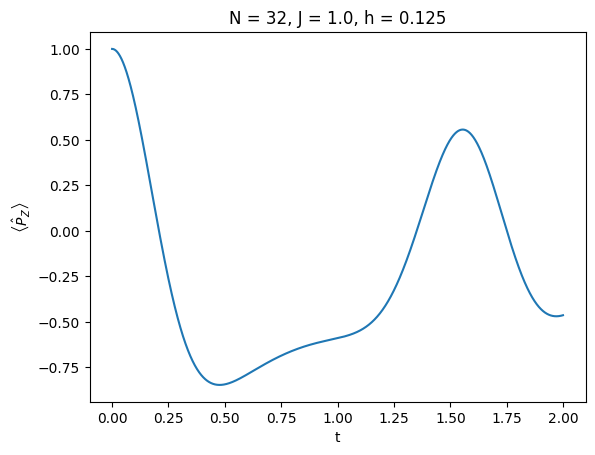

In [10]:
T = 2.0
tlist = np.arange(0.0, 2.0, 0.0005)
pZlist = []
pZlist2 = []
J = 1.0
h = 1.0/8
N = 32
for t in tlist:
    r1, r2 = parity_Z(N, J, h, t)
    pZlist.append(r1)
    pZlist2.append(r2)
plt.title(f"N = {N}, J = {J}, h = {h}")
plt.plot(tlist,pZlist)
plt.ylabel(r"$\left<\hat P_Z\right>$")
plt.xlabel(r"t")

In [11]:
import os
save_path = f"./data/TFIM_exact_parity/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
np.save(save_path + f"times_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy", tlist)
np.save(save_path + f"parityZ_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy", pZlist)